# Vanilla HNSW

In [1]:
import struct
import numpy as np
import torch
import torch.nn.functional as F
import heapq
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import time
import matplotlib.pyplot as plt

def read_fvecs(path: str) -> np.ndarray:
    """Read .fvecs file into (N, d) float32 array."""
    with open(path, 'rb') as f:
        vecs = []
        while True:
            hdr = f.read(4)
            if not hdr:
                break
            d = struct.unpack('i', hdr)[0]
            data = struct.unpack('f' * d, f.read(4 * d))
            vecs.append(data)
    return np.vstack(vecs).astype('float32')


def read_ivecs(path: str) -> np.ndarray:
    """Read .ivecs file into (N, k) int array."""
    with open(path, 'rb') as f:
        idxs = []
        while True:
            hdr = f.read(4)
            if not hdr:
                break
            k = struct.unpack('i', hdr)[0]
            data = struct.unpack('i' * k, f.read(4 * k))
            idxs.append(data)
    return np.vstack(idxs).astype('int64')

# ----------------------------
# Select GPU or CPU
# ----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
display(device)

/home/nishuz/Desktop/College/Data_Science/project/venv/lib/python3.12/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


device(type='cpu')

In [2]:
class HNSWIndexTorch:
    def __init__(self, M=16, ef_construction=200, ef_search=200,
                 metric='l2', device=None):
        """
        M: max neighbors per node
        ef_construction: candidate pool size during construction
        ef_search: pool size during search
        metric: 'l2' or 'cosine'
        """
        self.M = M
        self.ef_construction = ef_construction
        self.ef_search = ef_search
        self.metric = metric
        self.device = device or torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # will be set in fit()
        self.data = None              # torch.Tensor (N, d)
        self.levels = []              # list of dict {'nodes': [...], 'neighbors': {...}}
        self.max_level = 0
        self.entry_point = None

    def _distance_batch(self, q: torch.Tensor, pts: torch.Tensor) -> torch.Tensor:
        # q: (d,), pts: (n, d)
        if self.metric == 'l2':
            return torch.norm(pts - q.unsqueeze(0), dim=1)
        # cosine distance
        qn = F.normalize(q.unsqueeze(0), dim=1)
        pn = F.normalize(pts, dim=1)
        return 1 - (qn @ pn.t()).squeeze(0)

    def _dist_scalar(self, a: int, b: int) -> float:
        # still only used sparingly (backlink eviction)
        if self.metric == 'l2':
            return float(torch.norm(self.data[a] - self.data[b]).item())
        return float(1 - torch.dot(self.data[a], self.data[b]).item())

    def _select_diverse(self,
                        cand_idxs: torch.Tensor,
                        cand_dists: torch.Tensor,
                        M: int) -> list:
        """
        Vectorized greedy diversify on GPU.
        cand_idxs: (K,) tensor of candidate node indices
        cand_dists: (K,) tensor of their distances to the query
        """
        selected = []
        device = cand_idxs.device

        for _ in range(M):
            if len(selected) == 0:
                # pick global min
                _, argmin = cand_dists.min(dim=0)
                sel = int(cand_idxs[argmin].item())
            else:
                sel_tensor = torch.tensor(selected, device=device)       # (S,)
                pts_cand = self.data[cand_idxs]                          # (K, d)
                pts_sel  = self.data[sel_tensor]                          # (S, d)
                # all pairwise distances: (K, S)
                d_cs = torch.cdist(pts_cand, pts_sel, p=2)
                min_d_cs, _ = d_cs.min(dim=1)                             # (K,)

                # enforce diversification: min_d_cs >= cand_dists
                mask = min_d_cs >= cand_dists
                valid = cand_dists.clone()
                valid[~mask] = float('inf')

                _, argmin = valid.min(dim=0)
                sel = int(cand_idxs[argmin].item())

            selected.append(sel)

            # remove sel from the candidate pool
            keep = cand_idxs != sel
            cand_idxs  = cand_idxs[keep]
            cand_dists = cand_dists[keep]
            if cand_idxs.numel() == 0:
                break

        # if fewer than M, pad with next-best
        if len(selected) < M and cand_idxs.numel() > 0:
            need = M - len(selected)
            _, argmins = cand_dists.topk(k=need, largest=False)
            selected.extend([int(x.item()) for x in cand_idxs[argmins]])

        return selected

    def fit(self, data_np: np.ndarray):
        """Build the HNSW index on GPU."""
        # load data
        pts = torch.from_numpy(data_np).to(self.device)
        if self.metric == 'cosine':
            pts = F.normalize(pts, dim=1)
        self.data = pts
        N, d = pts.shape

        # assign levels (geom. distribution)
        levels = torch.from_numpy(
            np.random.geometric(1.0 - 1.0/self.M, size=N) - 1
        ).to(self.device)
        self.max_level = int(levels.max().item())

        # init layers
        self.levels = [
            {'nodes': [], 'neighbors': {}} for _ in range(self.max_level + 1)
        ]

        # incremental insertion
        for i in tqdm(range(N), desc='HNSW build'):
            lvl = int(levels[i].item())
            qi = pts[i]
            for layer in range(lvl + 1):
                lyr = self.levels[layer]
                nodes = lyr['nodes']
                if not nodes:
                    nodes.append(i)
                    lyr['neighbors'][i] = []
                    continue

                # compute distances to existing nodes in batch
                node_tensor = torch.tensor(nodes, device=self.device)
                dists = self._distance_batch(qi, pts[node_tensor])         # (len(nodes),)

                # pick top ef_construction candidates
                k = min(self.ef_construction, len(nodes))
                vals, inds = torch.topk(dists, k=k, largest=False)
                cand_idxs  = node_tensor[inds]                              # (k,)
                cand_dists = vals                                           # (k,)

                # diversify-select M on GPU
                selected = self._select_diverse(cand_idxs, cand_dists, self.M)

                # store neighbors & backlink
                lyr['neighbors'][i] = selected
                for j in selected:
                    nbrs_j = lyr['neighbors'].setdefault(j, [])
                    if len(nbrs_j) < self.M:
                        nbrs_j.append(i)
                    else:
                        # evict worst if needed
                        nbrs_tensor = torch.tensor(nbrs_j, device=self.device)
                        d_j = self._distance_batch(pts[j], pts[nbrs_tensor])
                        worst_idx = int(d_j.argmax().item())
                        worst_node = nbrs_j[worst_idx]
                        dist_i_j = self._dist_scalar(i, j)
                        if dist_i_j < d_j[worst_idx].item():
                            nbrs_j[worst_idx] = i
                    lyr['neighbors'][j] = nbrs_j

                nodes.append(i)

        # pick entry point: node in top layer closest to centroid
        cent = pts.mean(dim=0)
        top_nodes = self.levels[self.max_level]['nodes']
        top_tensor = torch.tensor(top_nodes, device=self.device)
        d_top = self._distance_batch(cent, pts[top_tensor])
        best_i = int(d_top.argmin().item())
        self.entry_point = top_nodes[best_i]

    def search(self, query_np: np.ndarray, k=10) -> list:
        """k-NN search with HNSW."""
        q = torch.from_numpy(query_np).to(self.device)
        if self.metric == 'cosine':
            q = F.normalize(q, dim=0)

        ep = self.entry_point
        # 1) greedy descent
        for layer in range(self.max_level, 0, -1):
            nodes = self.levels[layer]['nodes']
            nbrmap = self.levels[layer]['neighbors']
            if ep not in nodes:
                node_tensor = torch.tensor(nodes, device=self.device)
                dists = self._distance_batch(self.data[ep], self.data[node_tensor])
                ep = int(node_tensor[dists.argmin()].item())

            improved = True
            while improved:
                improved = False
                nbrs = nbrmap[ep]
                if not nbrs:
                    break
                nbr_pts = self.data[nbrs]
                d_n = self._distance_batch(q, nbr_pts)
                best_i = int(d_n.argmin().item())
                if d_n[best_i].item() < self._distance_batch(q, self.data[ep:ep+1]).item():
                    ep = nbrs[best_i]
                    improved = True

        # 2) best-first search on layer 0
        visited = {ep}
        C = [(float(self._distance_batch(q, self.data[ep:ep+1])), ep)]
        W = [(-C[0][0], ep)]

        while C:
            dist_u, u = heapq.heappop(C)
            worst_dist = -W[0][0]
            if len(W) >= self.ef_search and dist_u > worst_dist:
                break
            for v in self.levels[0]['neighbors'][u]:
                if v in visited:
                    continue
                visited.add(v)
                dv = float(self._distance_batch(q, self.data[v:v+1]))
                if len(W) < self.ef_search or dv < worst_dist:
                    heapq.heappush(C, (dv, v))
                    heapq.heappush(W, (-dv, v))
                    if len(W) > self.ef_search:
                        heapq.heappop(W)
                    worst_dist = -W[0][0]

        result = [node for (_, node) in W]
        result.sort(key=lambda node: float(self._distance_batch(q, self.data[node:node+1])))
        return result[:k]

def recall_at_k(preds, gt, k=10):
    hits = 0
    n = len(preds)
    for i in range(n):
        hits += len(set(preds[i][:k]) & set(gt[i][:k]))
    print(hits)
    return hits / (n * k)

def recall_at_k(preds, gt, k=10):
    hits = 0
    n = len(preds)
    for i in range(n):
        hits += len(set(preds[i][:k]) & set(gt[i][:k]))
    print(hits)
    return hits / (n * k)

In [3]:
class VAE(nn.Module):
    def __init__(self, D=128, D_latent=32):
        super().__init__()
        # encoder
        self.fc1 = nn.Linear(D, 64)
        self.fc_mu = nn.Linear(64, D_latent)
        self.fc_logvar = nn.Linear(64, D_latent)
        # decoder
        self.fc3 = nn.Linear(D_latent, 64)
        self.fc4 = nn.Linear(64, D)

    def encode(self, x):
        h = F.relu(self.fc1(x))
        return self.fc_mu(h), self.fc_logvar(h)

    def reparam(self, mu, logvar):
        std = (0.5*logvar).exp()
        eps = torch.randn_like(std)
        return mu + eps*std

    def decode(self, z):
        h = F.relu(self.fc3(z))
        return self.fc4(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparam(mu, logvar)
        return self.decode(z), mu, logvar
    
def train_vae(base_np, gt_base, knn_bb,
              D_latent, device,
              epochs=30, batch_size=256,
              lr=1e-3, wd=1e-5,
              margin=0.2, tri_w=1.0,
              beta_kl=1.0):
    """
    VAE training with reconstruction + KL + optional triplet loss.
    """
    ds     = TensorDataset(torch.from_numpy(base_np).float(),
                           torch.arange(len(base_np)))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=True)

    vae = VAE(D=base_np.shape[1], D_latent=D_latent).to(device)
    opt = optim.Adam(vae.parameters(), lr=lr, weight_decay=wd)

    for ep in range(1, epochs+1):
        vae.train()
        tot_rec = tot_kl = tot_tri = 0.0

        for x, idx_tensor in loader:
            x   = x.to(device)
            idx = idx_tensor.cpu().numpy()

            # forward
            recon, mu, logvar = vae(x)
            # rec loss
            loss_rec = F.mse_loss(recon, x)
            # KL divergence
            loss_kl  = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
            
            # optional triplet:
            pos_idx = [ np.random.choice(gt_base[i])  for i in idx ]
            neg_idx = [ np.random.choice(knn_bb[i])    for i in idx ]
            xp = torch.from_numpy(base_np[pos_idx]).float().to(device)
            xn = torch.from_numpy(base_np[neg_idx]).float().to(device)
            _, mu_p, _ = vae(xp)
            _, mu_n, _ = vae(xn)
            d_pos = (mu - mu_p).pow(2).sum(1)
            d_neg = (mu - mu_n).pow(2).sum(1)
            loss_tri = F.relu(d_pos - d_neg + margin).mean()

            loss = loss_rec + beta_kl * loss_kl + tri_w * loss_tri

            opt.zero_grad()
            loss.backward()
            opt.step()

            tot_rec += loss_rec.item()
            tot_kl  += loss_kl.item()
            tot_tri += loss_tri.item()

        print(f"[VAE] Epoch {ep}/{epochs}  "
              f"Rec={tot_rec/len(loader):.4e}  "
              f"KL={tot_kl/len(loader):.4e}  "
              f"Tri={tot_tri/len(loader):.4e}")
    return vae


def encode_vae(vae, data_np, device, batch_size=256):
    """
    Encode with the VAE’s mean (mu) as the embedding.
    """
    vae.eval()
    loader = DataLoader(TensorDataset(torch.from_numpy(data_np).float()),
                        batch_size=batch_size)
    latents = []
    with torch.no_grad():
        for (x,) in loader:
            mu, logvar = vae.encode(x.to(device))
            latents.append(mu.cpu().numpy())
    return np.vstack(latents)

In [4]:
from torchvision import datasets, transforms
import numpy as np

# 1) Load MNIST
tr = datasets.MNIST(root='.', train=True,  download=True, transform=transforms.ToTensor())
te = datasets.MNIST(root='.', train=False, download=True, transform=transforms.ToTensor())

# 2) Stack into (N,784) float32 arrays
base_full  = np.stack([img.numpy().reshape(-1) for img,_ in tr]).astype('float32')  # (60000,784)
query_full = np.stack([img.numpy().reshape(-1) for img,_ in te]).astype('float32')  # (10000,784)

# 3) Subsample base if N is set
N = 5000    # <-- set to desired number of points, or None to keep all
if N is not None:
    # random subsample of N indices (no replacement)
    idx = np.random.choice(base_full.shape[0], size=N, replace=False)
    idx_ = np.random.choice(query_full.shape[0], size=500, replace=False)
    base = base_full[idx]
    query = query_full[idx_]
else:
    base = base_full
    query = query_full

print(f"Using {base.shape[0]} base points")
print(f"Using {query.shape[0]} query points")

from sklearn.neighbors import NearestNeighbors

# 1) Fit brute‑force NN on your base set
knn_qb = NearestNeighbors(
    n_neighbors=10,
    algorithm='brute',
    metric='euclidean',
    n_jobs=-1
)
knn_qb.fit(base)
distances, gt2 = knn_qb.kneighbors(query)


# 3) Compute base→base GT for triplet training:
#    We need the 10 nearest *other* points for each base vector,
#    and also the next 50 for hard negatives.

# Fit again asking for 51 neighbors (self + 50 others)
knn_bb_model = NearestNeighbors(
    n_neighbors=51,
    algorithm='brute',
    metric='euclidean',
    n_jobs=-1
)
knn_bb_model.fit(base)
dists_bb, idxs_bb = knn_bb_model.kneighbors(base)

# Now split into gt_base (first 10 *non‑self* neighbors)
# and knn_bb (next 50 for negatives)
gt_base = idxs_bb[:, 1:11]      # shape (60000,10)
knn_bb  = idxs_bb[:, 1:51]      # shape (60000,50)


# 4) Settings to sweep
latent_dims = [8,16,32,64]
rerank_flags = [False, True]

results = []  # (mode, D_latent, rerank, recall, build_t, query_t, rerank_t)

# 5)  Baseline: raw HNSW
for rerank in rerank_flags:
    start = time.time()
    idx_raw = HNSWIndexTorch(M=32, ef_construction=200, ef_search=400, metric='l2', device=device)
    idx_raw.fit(base)
    build_t = time.time() - start

    # query
    t_q = t_r = 0.0
    preds = []
    for q in tqdm(query, desc=f"Query Raw rerank={rerank}"):
        t0 = time.time()
        cand = idx_raw.search(q, k=50)
        t_q += time.time() - t0
        if rerank:
            t0 = time.time()
            # re-rank in full 128-D
            dists = np.linalg.norm(base[cand] - q, axis=1)
            cand = list(np.array(cand)[np.argsort(dists)[:10]])
            t_r += time.time() - t0
        else:
            cand = cand[:10]
        preds.append(cand)
    rec = recall_at_k(preds, gt2, k=10)
    results.append(("raw", None, rerank, rec, build_t, t_q, t_r))

# 6) Learned compressor + HNSW (with VAE + optional rerank)
for D_latent in latent_dims:
    # a) train VAE
    vae = train_vae(
        base_np    = base,
        gt_base    = gt_base,
        knn_bb     = knn_bb,
        D_latent   = D_latent,
        device     = device,
        epochs     = 20,
        batch_size = 256,
        lr         = 5e-4,
        wd         = 1e-6,
        margin     = 1.0,
        tri_w      = 1.0,
        beta_kl    = 1.0
    )

    # b) encode via the VAE’s mu
    base_lat  = encode_vae(vae, base,  device)
    query_lat = encode_vae(vae, query, device)

    # c) build the index once per latent dim
    start = time.time()
    idx_lat = HNSWIndexTorch(M=32,
                             ef_construction=200,
                             ef_search=400,
                             metric='l2',
                             device=device)
    idx_lat.fit(base_lat)
    build_t = time.time() - start

    # d) loop over with/without reranking
    for rerank in rerank_flags:
        t_q = t_r = 0.0
        preds = []
        for i, qz in enumerate(tqdm(query_lat, desc=f"Query Lat{D_latent} rerank={rerank}")):
            # ANN in latent space
            t0 = time.time()
            cand = idx_lat.search(qz, k=50)
            t_q += time.time() - t0

            if rerank:
                # full‑space re‑rank top‑50 → top‑10
                t1 = time.time()
                dists = np.linalg.norm(base[cand] - query[i], axis=1)
                top10 = np.argsort(dists)[:10]
                cand = list(np.array(cand)[top10])
                t_r += time.time() - t1
            else:
                cand = cand[:10]

            preds.append(cand)

        rec = recall_at_k(preds, gt2, k=10)
        results.append(("vae", D_latent, rerank, rec, build_t, t_q, t_r))


Using 5000 base points
Using 500 query points


Query Raw rerank=False: 100%|██████████| 500/500 [00:08<00:00, 61.24it/s]


4999


Query Raw rerank=True: 100%|██████████| 500/500 [00:08<00:00, 57.03it/s]


5000
[VAE] Epoch 1/20  Rec=1.4940e-01  KL=6.7878e-03  Tri=9.9102e-01
[VAE] Epoch 2/20  Rec=1.1198e-01  KL=1.1731e-02  Tri=9.6968e-01
[VAE] Epoch 3/20  Rec=9.5292e-02  KL=3.7150e-02  Tri=8.9318e-01
[VAE] Epoch 4/20  Rec=8.6563e-02  KL=6.6696e-02  Tri=8.3500e-01
[VAE] Epoch 5/20  Rec=8.1174e-02  KL=7.1587e-02  Tri=8.0872e-01
[VAE] Epoch 6/20  Rec=7.7890e-02  KL=7.7246e-02  Tri=7.7511e-01
[VAE] Epoch 7/20  Rec=7.5807e-02  KL=7.9638e-02  Tri=7.6387e-01
[VAE] Epoch 8/20  Rec=7.4195e-02  KL=8.5687e-02  Tri=7.4144e-01
[VAE] Epoch 9/20  Rec=7.2846e-02  KL=9.1331e-02  Tri=7.3180e-01
[VAE] Epoch 10/20  Rec=7.1909e-02  KL=9.2851e-02  Tri=7.2335e-01
[VAE] Epoch 11/20  Rec=7.1095e-02  KL=9.5488e-02  Tri=7.1775e-01
[VAE] Epoch 12/20  Rec=7.0696e-02  KL=9.5965e-02  Tri=7.1639e-01
[VAE] Epoch 13/20  Rec=7.0212e-02  KL=9.5595e-02  Tri=7.0717e-01
[VAE] Epoch 14/20  Rec=6.9574e-02  KL=9.8828e-02  Tri=7.0649e-01
[VAE] Epoch 15/20  Rec=6.9226e-02  KL=9.7921e-02  Tri=7.0243e-01
[VAE] Epoch 16/20  Rec=6.8651

...

4667
[VAE] Epoch 1/20  Rec=1.4645e-01  KL=2.0324e-02  Tri=8.8755e-01
[VAE] Epoch 2/20  Rec=1.1273e-01  KL=4.5016e-02  Tri=7.1060e-01
[VAE] Epoch 3/20  Rec=9.8095e-02  KL=5.0546e-02  Tri=6.2579e-01
[VAE] Epoch 4/20  Rec=8.8804e-02  KL=4.7585e-02  Tri=5.8251e-01
[VAE] Epoch 5/20  Rec=8.2531e-02  KL=4.7079e-02  Tri=5.4993e-01
[VAE] Epoch 6/20  Rec=7.8187e-02  KL=5.0222e-02  Tri=5.4074e-01
[VAE] Epoch 7/20  Rec=7.5234e-02  KL=4.8760e-02  Tri=5.3352e-01
[VAE] Epoch 8/20  Rec=7.3327e-02  KL=4.7970e-02  Tri=5.0705e-01
[VAE] Epoch 9/20  Rec=7.1295e-02  KL=5.1102e-02  Tri=4.8676e-01
[VAE] Epoch 10/20  Rec=6.9775e-02  KL=5.2717e-02  Tri=4.9277e-01
[VAE] Epoch 11/20  Rec=6.8621e-02  KL=5.2233e-02  Tri=4.8212e-01
[VAE] Epoch 12/20  Rec=6.7586e-02  KL=5.0844e-02  Tri=4.7319e-01
[VAE] Epoch 13/20  Rec=6.6646e-02  KL=5.0526e-02  Tri=4.4952e-01
[VAE] Epoch 14/20  Rec=6.5403e-02  KL=5.1323e-02  Tri=4.3529e-01
[VAE] Epoch 15/20  Rec=6.4626e-02  KL=5.1413e-02  Tri=4.4198e-01
[VAE] Epoch 16/20  Rec=6.4341

Query Lat64 rerank=False: 100%|██████████| 500/500 [00:07<00:00, 64.03it/s]


3214


Query Lat64 rerank=True: 100%|██████████| 500/500 [00:07<00:00, 66.48it/s]

4804


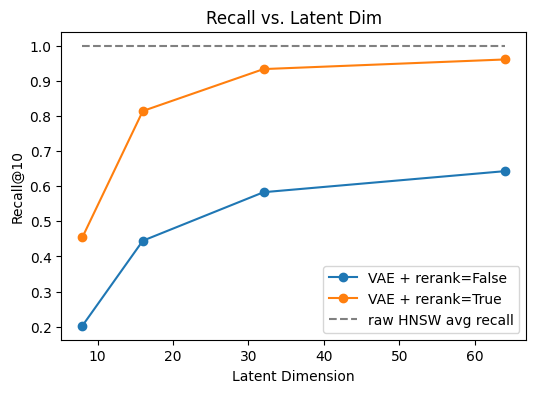

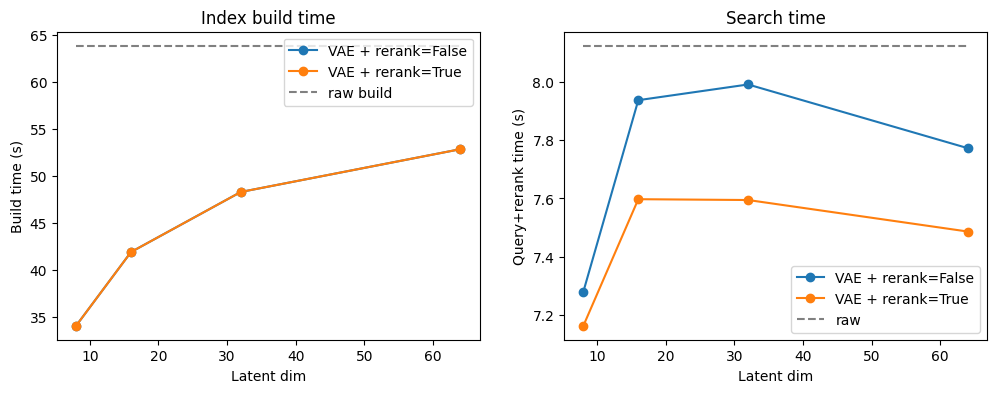

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame(results, columns=[
    "mode","D_lat","rerank","recall","build","query","rerank_time"
])

# 1) Recall vs Latent Dim
plt.figure(figsize=(6,4))
for rerank_flag in [False, True]:
    sub = df[(df["mode"]=="vae") & (df["rerank"]==rerank_flag)]
    plt.plot(sub["D_lat"], sub["recall"], marker='o',
             label=f"VAE + rerank={rerank_flag}")
# raw baseline
raw_sub = df[df["mode"]=="raw"]
plt.hlines(raw_sub["recall"].mean(),
           xmin=min(latent_dims), xmax=max(latent_dims),
           linestyles='dashed', color='grey',
           label="raw HNSW avg recall")
plt.xlabel("Latent Dimension")
plt.ylabel("Recall@10")
plt.title("Recall vs. Latent Dim")
plt.legend()
plt.show()

# 2) Build & Query time vs Latent Dim
fig, ax = plt.subplots(1,2, figsize=(12,4))

# Build time
for rer in [False, True]:
    sub = df[(df["mode"]=="vae") & (df["rerank"]==rer)]
    ax[0].plot(sub["D_lat"], sub["build"], marker='o',
               label=f"VAE + rerank={rer}")
ax[0].hlines(df[df["mode"]=="raw"]["build"].mean(),
             xmin=min(latent_dims), xmax=max(latent_dims),
             linestyles='dashed', color='grey',
             label="raw build")
ax[0].set_xlabel("Latent dim")
ax[0].set_ylabel("Build time (s)")
ax[0].set_title("Index build time")
ax[0].legend()

# Query + Re‑rank time
for rer in [False, True]:
    sub = df[(df["mode"]=="vae") & (df["rerank"]==rer)]
    total = sub["query"] + sub["rerank_time"]
    ax[1].plot(sub["D_lat"], total, marker='o',
               label=f"VAE + rerank={rer}")
# raw baseline
raw_df = df[df["mode"]=="raw"].copy()
raw_df["total_time"] = raw_df["query"] + raw_df["rerank_time"]
baseline_time = raw_df.groupby("rerank", as_index=False)["total_time"]\
                      .mean()\
                      .query("rerank==False")["total_time"].iloc[0]
ax[1].hlines(baseline_time,
             xmin=min(latent_dims), xmax=max(latent_dims),
             linestyles='dashed', color='grey',
             label="raw")
ax[1].set_xlabel("Latent dim")
ax[1].set_ylabel("Query+rerank time (s)")
ax[1].set_title("Search time")
ax[1].legend()

plt.show()
